<a href="https://colab.research.google.com/github/namratamaurya-da/ML/blob/main/Logistics_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Q1. Data Loading & Understanding**

**a) Load the dataset into Python.**

**b) Display the first 5 rows.**

**c) Check the shape of the dataset.**

**d) Display the data types of each column.**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel("/content/drive/MyDrive/PW Skills- DA/ML Assignment2- Logistics Regression/loan_approval.xlsx")

# Display the dataset
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [3]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2000, 8)


In [5]:
print(df.dtypes)

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


The dataset contains 2,000 observations and 8 columns. It includes customer information such as name and city, along with numerical variables including income, credit score, loan amount, years of employment, and points. The target variable is loan_approved, which indicates whether a loan application was approved or not.

**Q2. Data Cleaning**

**a) Check for missing values in the dataset.**

**b) Handle missing values appropriately.**

**c) Identify categorical columns present in the dataset.**


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


In [7]:
# Check total missing values
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [8]:
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['name', 'city', 'loan_approved'], dtype='object')


The dataset does not contain any missing values, so no missing-value treatment is required. The categorical columns are name, city, and loan_approved. The name column is an identifier and does not provide useful predictive information, while city has a very large number of unique values and is not required for the present Logistic Regression model. Therefore, these unnecessary columns can be removed before model building.

**Q3. Exploratory Data Analysis (EDA)**

**a) Plot the distribution of the target variable.**

**b) Analyze the relationship between one numerical feature and the target variable.**

**c) Analyze the relationship between Years of Employment and the target variable.**


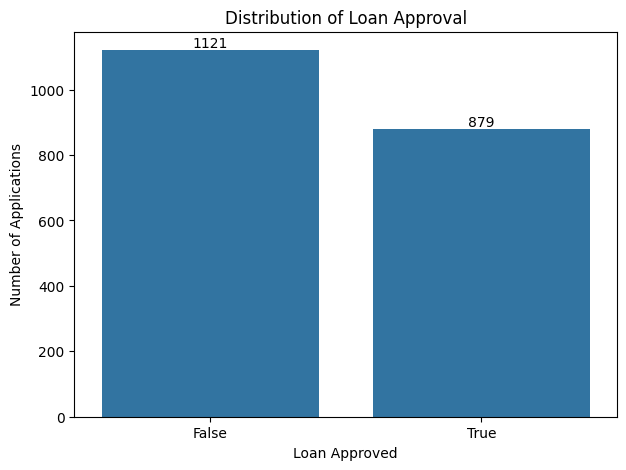

In [9]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="loan_approved")

plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applications")

# Add counts on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

The target variable contains two classes: approved and not approved. There are 1,121 applications that were not approved and 879 applications that were approved. Although the classes are not exactly equal, the difference is not extremely large, so the dataset does not show severe class imbalance.

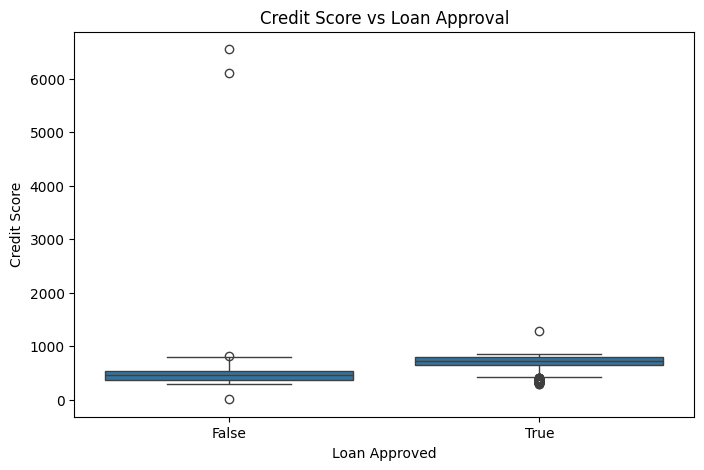

In [12]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df,
    x="loan_approved",
    y="credit_score"
)

plt.title("Credit Score vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")

plt.show()

In [15]:
print(
    df.groupby("loan_approved")["credit_score"]
      .mean()
      .round(2)
)

loan_approved
False    482.11
True     704.40
Name: credit_score, dtype: float64


Credit score shows a strong relationship with loan approval. The average credit score of approved applicants is approximately 704.40, compared with approximately 482.11 for applicants whose loans were not approved. This indicates that applicants with higher credit scores generally have a higher likelihood of loan approval.

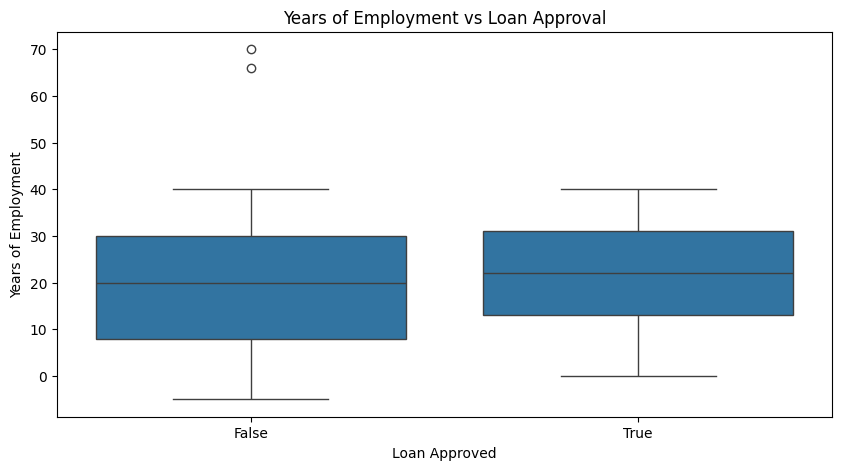

In [13]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="loan_approved",
    y="years_employed"
)

plt.title("Years of Employment vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Years of Employment")

plt.show()

In [14]:
print(
    df.groupby("loan_approved")["years_employed"]
      .mean()
      .round(2)
)

loan_approved
False    19.43
True     21.83
Name: years_employed, dtype: float64


Years of employment shows a relatively weaker relationship with loan approval compared with credit score. Approved applicants have an average employment duration of approximately 21.83 years, while non-approved applicants have an average of approximately 19.43 years. This suggests that longer employment may have a positive association with loan approval, although the relationship is not as strong as that of credit score.

**Q4. Outlier Detection and Treatment**

**a) Detect outliers in numerical columns using the IQR method.**

**b) Treat outliers using capping techniques**


In [16]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\nColumn: {col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


Column: income
Q1: 61296.25
Q3: 120099.75
IQR: 58803.5
Lower Bound: -26909.0
Upper Bound: 208305.0
Number of Outliers: 0

Column: credit_score
Q1: 433.0
Q3: 716.0
IQR: 283.0
Lower Bound: 8.5
Upper Bound: 1140.5
Number of Outliers: 3

Column: loan_amount
Q1: 12748.75
Q3: 37380.5
IQR: 24631.75
Lower Bound: -24198.875
Upper Bound: 74328.125
Number of Outliers: 0

Column: years_employed
Q1: 10.0
Q3: 31.0
IQR: 21.0
Lower Bound: -21.5
Upper Bound: 62.5
Number of Outliers: 2

Column: points
Q1: 45.0
Q3: 70.0
IQR: 25.0
Lower Bound: 7.5
Upper Bound: 107.5
Number of Outliers: 0


In [17]:
df_clean = df.copy()

numerical_cols = df_clean.select_dtypes(include=np.number).columns

for col in numerical_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping
    df_clean[col] = df_clean[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print(df_clean[numerical_cols].describe())

              income  credit_score   loan_amount  years_employed       points
count    2000.000000   2000.000000   2000.000000     2000.000000  2000.000000
mean    90585.977000    574.546250  25308.503000       20.476500    56.680000
std     34487.874907    162.442674  14207.320147       11.852993    18.638033
min     30053.000000     11.000000   1022.000000       -5.000000    10.000000
25%     61296.250000    433.000000  12748.750000       10.000000    45.000000
50%     90387.500000    576.000000  25661.500000       21.000000    55.000000
75%    120099.750000    716.000000  37380.500000       31.000000    70.000000
max    149964.000000   1140.500000  49999.000000       62.500000   100.000000


The IQR method identified three outliers in credit_score and two outliers in years_employed. No outliers were detected in income, loan amount, or points. Instead of removing the observations, IQR-based capping was applied so that extreme values were limited to the calculated lower and upper bounds. This preserves the observations while reducing the influence of extreme values on the Logistic Regression model.

**Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.**


In [18]:
# Convert target variable into numerical format
df_clean["loan_approved"] = df_clean["loan_approved"].astype(int)

# Drop unnecessary columns
df_model = df_clean.drop(columns=["name", "city"])

print(df_model.head())
print(df_model.dtypes)

   income  credit_score  loan_amount  years_employed  points  loan_approved
0  113810         389.0        39698            27.0      50              0
1   44592         729.0        15446            28.0      55              0
2   33278         584.0        11189            13.0      45              0
3  127196         344.0        48823            29.0      50              0
4   66048         496.0        47174             4.0      25              0
income              int64
credit_score      float64
loan_amount         int64
years_employed    float64
points              int64
loan_approved       int64
dtype: object


The target variable loan_approved was converted from Boolean format to numerical format, where 0 represents loan not approved and 1 represents loan approved. The name and city columns were dropped because name is an identifier and city contains a very high number of unique categories. The remaining numerical variables were retained as predictors.

**Q6. Feature Selection and Data Splitting**

**a) Separate independent variables (X) and dependent variable (y).**

**b) Split the dataset into training and testing sets.**

In [19]:
X = df_model.drop(columns=["loan_approved"])
y = df_model["loan_approved"]

print("Independent variables:")
print(X.columns)

print("\nDependent variable:")
print(y.name)

Independent variables:
Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points'], dtype='object')

Dependent variable:
loan_approved


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1600, 5)
Testing set shape: (400, 5)


The dataset was divided into independent variables (X) and the dependent variable (y). An 80:20 train-test split was applied, resulting in 1,600 observations for training and 400 observations for testing. Stratification was used to maintain a similar proportion of approved and non-approved loans in both datasets.

**Q7. Apply feature scaling to the dataset using StandardScaler.**

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


StandardScaler was applied to standardize the independent variables. Scaling transforms the features so that they have approximately zero mean and unit variance. The scaler was fitted only on the training data and then applied to both the training and testing data to avoid data leakage.

**Q8. Logistic Regression Model Building**

**a) Train a Logistic Regression model.**

**b) Predict the output for test data.**


In [22]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [23]:
y_pred = logistic_model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred[:20])

Predicted values:
[1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]


In [24]:
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predicted probabilities:")
print(y_prob[:10])

Predicted probabilities:
[7.71071761e-01 2.28948757e-06 9.94590445e-01 9.99956713e-01
 2.18862902e-06 1.00000000e+00 9.82318023e-03 9.99998630e-01
 1.30136277e-01 2.17204433e-06]


**Q9. Model Evaluation – Confusion Matrix**

**a) Generate the confusion matrix.**

**b) Interpret the results.**


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[224   0]
 [  0 176]]


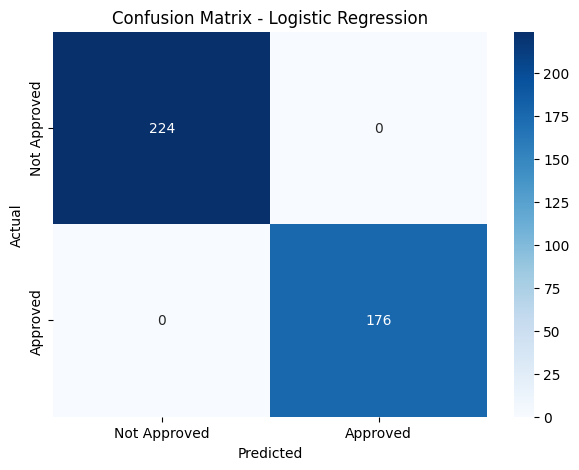

In [26]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified all 224 non-approved loans and all 176 approved loans in the test dataset. There were no false positives and no false negatives. Therefore, the model achieved perfect classification on the test set. This indicates that the selected features, particularly points and credit_score, provide very strong separation between the two loan approval classes in this dataset.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


The Logistic Regression model achieved an accuracy, precision, recall, and F1-score of 1.00 on the test dataset. This means that every observation in the test set was classified correctly. The model produced neither false-positive nor false-negative predictions.

**Q10. Model Evaluation – ROC Curve & AUC**

**a) Plot the ROC curve.**

**b) Calculate the AUC score.**

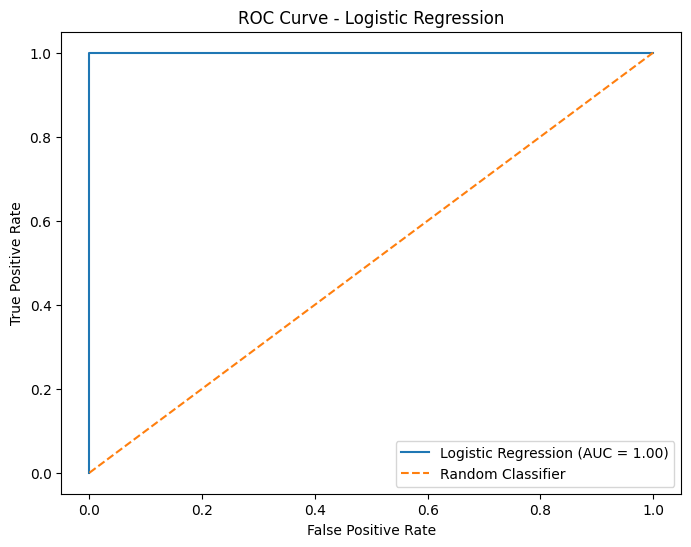

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [29]:

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 1.0


The ROC curve shows perfect separation between approved and non-approved loan applications. The AUC score is 1.00, indicating that the model has perfect ability to distinguish between the two classes on the test dataset. An AUC of 1.00 represents perfect classification performance.